# Low-Carbon Commuting Adoption Simulation

**Research question:**  
Does targeting central individuals lead to higher adoption of low-carbon commuting than targeting random initial adopters in a social network simulation?

In this notebook, we build a simple agent-based simulation for low-carbon commuting adoption. Each person is represented as a node in a social network. Some people adopt low-carbon commuting at the start, and others adopt later if enough of their connected people have already adopted.


## 1. Project idea and model logic

In this project, we compared two targeting strategies:

1. **Random targeting:** initial adopters are chosen randomly.
2. **Central targeting:** initial adopters are the most connected individuals in the network.

The main idea is to test whether starting with well-connected individuals creates stronger and more reliable adoption of low-carbon commuting.

Low-carbon commuting can mean walking, cycling, public transport, car sharing, or carpooling instead of private car use.


## 2. Imports




In [ ]:
import networkx as nx
import random
import pandas as pd
import matplotlib.pyplot as plt

## 3. Parameters

These values define the size of the simulation and the conditions we test.


In [ ]:
N = 1000 # Number of people in the simulation
m = 3 # 3 connections per person

initial_adopter_fraction = 0.05 # 0.05 means 5%

time_steps = 50


thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

repetitions = 100

strategies = ["random", "central"]

random_seed = 42
random.seed(random_seed)

## 4. Create and inspect the network

We use a **scale-free network**. In this type of network, most people have few connections, while a few people are highly connected. This is useful because our project compares random targeting with central targeting.


In [ ]:
def create_network(N, m):
    G = nx.barabasi_albert_graph(N, m)

    return G
G = create_network(N, m)

print("Number of people:", G.number_of_nodes())
print("Number of connections:", G.number_of_edges())

Number of people: 1000
Number of connections: 2991


## 5. Choosing initial adopters

This function chooses the first people who already adopted low-carbon commuting.

- In the random strategy, adopters are chosen randomly.
- In the central strategy, adopters are the most connected people.


In [ ]:
def choose_initial_adopters(G, strategy, fraction):
    number_of_initial_adopters = int(G.number_of_nodes() * fraction)

    if strategy == "random":
        initial_adopters = random.sample(
            list(G.nodes()),
            number_of_initial_adopters
        )

    elif strategy == "central":
        degrees = dict(G.degree())


        sorted_people = sorted(
            degrees,
            key=degrees.get,
            reverse=True
        )

        initial_adopters = sorted_people[:number_of_initial_adopters]

    else:
        raise ValueError("Strategy must be either 'random' or 'central'.")

    return set(initial_adopters)

### Check initial adopter selection

This check confirms that both strategies select the same number of initial adopters.


In [ ]:
random_initial = choose_initial_adopters(
    G,
    strategy="random",
    fraction=initial_adopter_fraction
)

central_initial = choose_initial_adopters(
    G,
    strategy="central",
    fraction=initial_adopter_fraction
)

print("Number of random initial adopters:", len(random_initial))
print("Number of central initial adopters:", len(central_initial))

print("Some random initial adopters:", list(random_initial)[:10])
print("Some central initial adopters:", list(central_initial)[:10])

Number of random initial adopters: 50
Number of central initial adopters: 50
Some random initial adopters: [390, 905, 638, 907, 140, 411, 540, 287, 33, 290]
Some central initial adopters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


##6. Running adoption simulation

In [ ]:
def run_simulation(G, initial_adopters, threshold, time_steps):

    adopters = set(initial_adopters)

    adoption_over_time = []
    for step in range(time_steps):

        adoption_rate = len(adopters) / G.number_of_nodes()
        adoption_over_time.append(adoption_rate)
        new_adopters = set()

        for person in G.nodes():

            if person in adopters:
                continue

            neighbors = list(G.neighbors(person))

            if len(neighbors) == 0:
                continue

            adopted_neighbors = 0

            for neighbor in neighbors:
                if neighbor in adopters:
                    adopted_neighbors += 1

            fraction_adopted_neighbors = adopted_neighbors / len(neighbors)

            if fraction_adopted_neighbors >= threshold:
                new_adopters.add(person)

        if len(new_adopters) == 0:
            break
        adopters.update(new_adopters)

    final_adoption_rate = len(adopters) / G.number_of_nodes()
    return final_adoption_rate, adoption_over_time

### Running Simulation first for threshold 0.3

In [ ]:
final_rate_random, adoption_time_random = run_simulation(
    G,
    random_initial,
    threshold=0.3,
    time_steps=time_steps
)

print("Final adoption rate with random initial adopters:", final_rate_random)
print("Adoption over time:", adoption_time_random)

Final adoption rate with random initial adopters: 0.121
Adoption over time: [0.05, 0.104, 0.114, 0.121]


In [ ]:
final_rate_central, adoption_time_central = run_simulation(
    G,
    central_initial,
    threshold=0.3,
    time_steps=time_steps
)

print("Final adoption rate with central initial adopters:", final_rate_central)
print("Adoption over time:", adoption_time_central)

Final adoption rate with central initial adopters: 1.0
Adoption over time: [0.05, 0.505, 0.849, 0.993, 1.0]


## 7. First test result

We tested the model once with threshold = 0.3. This means a person adopts low-carbon commuting if at least 30% of their connected people have already adopted it.

With random initial adopters, final adoption reached 12.6% which means the behavior spread only a little and then stopped.

With central initial adopters, final adoption reached 100% and that shows that the behavior spread very quickly through the whole network.

This clearly shows that central targeting can create a much stronger adoption rate than random targeting. However, this is only one simulation run, so in the next step we will repeat the experiment many times and test different threshold values.

##Visualization of first run

This following graph is only a first test run with threshold = 0.3. It shows that the simulation works and that central initial adopters can create a much faster adoption cascade than random initial adopters.

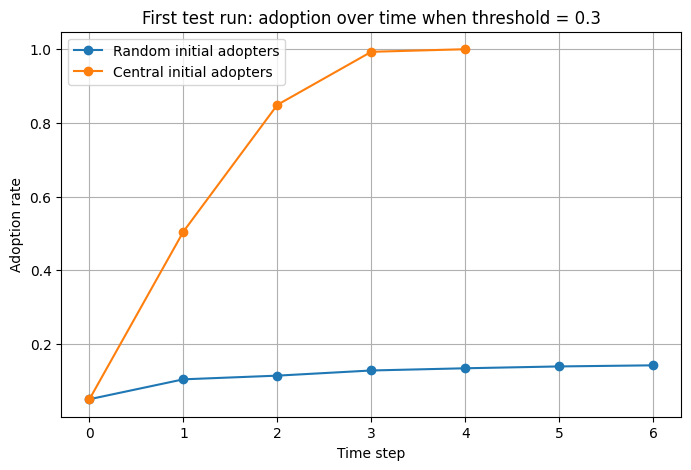

In [ ]:

plt.figure(figsize=(8, 5))

plt.plot(
    adoption_time_random,
    marker="o",
    label="Random initial adopters"
)

plt.plot(
    adoption_time_central,
    marker="o",
    label="Central initial adopters"
)

plt.xlabel("Time step")
plt.ylabel("Adoption rate")
plt.title("First test run: adoption over time when threshold = 0.3")
plt.legend()
plt.grid(True)
plt.show()

## 8.Repeated Experiment

In [ ]:
results = []

time_series_results = []

for threshold in thresholds:

    for strategy in strategies:

        for repetition in range(repetitions):

            G = create_network(N, m)
            initial_adopters = choose_initial_adopters(
                G,
                strategy=strategy,
                fraction=initial_adopter_fraction
            )

            final_adoption_rate, adoption_over_time = run_simulation(
                G,
                initial_adopters,
                threshold=threshold,
                time_steps=time_steps
            )

            results.append({
                "threshold": threshold,
                "strategy": strategy,
                "repetition": repetition,
                "final_adoption_rate": final_adoption_rate
            })

            for time, adoption_rate in enumerate(adoption_over_time):
                time_series_results.append({
                    "threshold": threshold,
                    "strategy": strategy,
                    "repetition": repetition,
                    "time": time,
                    "adoption_rate": adoption_rate
                })

results_df = pd.DataFrame(results)
time_series_df = pd.DataFrame(time_series_results)

results_df.head()

,threshold,strategy,repetition,final_adoption_rate
0,0.1,random,0,1.0
1,0.1,random,1,1.0
2,0.1,random,2,1.0
3,0.1,random,3,1.0
4,0.1,random,4,1.0


In [ ]:
summary = results_df.groupby(["threshold", "strategy"])["final_adoption_rate"].mean().reset_index()
summary

,threshold,strategy,final_adoption_rate
0,0.1,central,1.00000
1,0.1,random,1.00000
2,0.2,central,1.00000
3,0.2,random,1.00000
4,0.3,central,1.00000
5,0.3,random,0.33595
6,0.4,central,1.00000
7,0.4,random,0.05909
8,0.5,central,0.98229
9,0.5,random,0.05564


### Interpretation

At low thresholds, 0.1 and 0.2, both strategies reached full adoption. This means that when people are easy to influence, the behavior spreads widely even if the first adopters are chosen randomly.

At medium and high thresholds, the difference became very large. At threshold 0.3, central targeting reached full adoption, while random targeting reached only about 32.47%. At thresholds 0.4 and 0.5, random targeting almost failed and stayed close to the initial 5%, while central targeting still reached almost the whole network.

##9. Statistical Analysis

### 9.1 Mean and Standard Deviation

In [ ]:

stats_summary = (
    results_df
    .groupby(["threshold", "strategy"])["final_adoption_rate"]
    .agg(["mean", "std"])
    .reset_index()
)

stats_summary

,threshold,strategy,mean,std
0,0.1,central,1.00000,0.000000
1,0.1,random,1.00000,0.000000
2,0.2,central,1.00000,0.000000
3,0.2,random,1.00000,0.000000
4,0.3,central,1.00000,0.000000
5,0.3,random,0.33595,0.365589
6,0.4,central,1.00000,0.000000
7,0.4,random,0.05909,0.004780
8,0.5,central,0.98229,0.101270
9,0.5,random,0.05564,0.003283


#### Summary of Mean Vs Standard Deviation


The mean and standard deviation show how adoption changes across 100 repeated simulations.

At low thresholds (0.1 and 0.2), both random and central targeting reached full adoption, with mean adoption equal to 1.0 and standard deviation 0. This means adoption spread to the whole network in every simulation.

At threshold 0.3, central targeting still reached full adoption in all simulations, while random targeting reached only about 32.5% on average. The standard deviation for random targeting is high, which means random targeting was unstable: in some runs it spread more, but in many runs it did not.

At thresholds 0.4 and 0.5, random targeting stayed close to the initial 5% adoption level, while central targeting still reached almost the whole network. This means that central targeting works much better when people need stronger social influence before adopting.

### 9.2 Difference between Central and Random

In [ ]:

comparison = stats_summary.pivot(
    index="threshold",
    columns="strategy",
    values="mean"
).reset_index()

comparison["central_minus_random"] = comparison["central"] - comparison["random"]

comparison

strategy,threshold,central,random,central_minus_random
0,0.1,1.00000,1.00000,0.00000
1,0.2,1.00000,1.00000,0.00000
2,0.3,1.00000,0.33595,0.66405
3,0.4,1.00000,0.05909,0.94091
4,0.5,0.98229,0.05564,0.92665


#### Summary of Central and Random


In this table we are directly comparing central targeting with random targeting.

At thresholds 0.1 and 0.2, the difference is 0 because both strategies reached full adoption. At threshold 0.3, central targeting produced about 67.5 percentage points more adoption than random targeting. At thresholds 0.4 and 0.5, the advantage of central targeting increased to about 94 percentage points.

This means that central targeting becomes more important when adoption is harder.

### 9.3 Cascade Probability

In [ ]:

results_df["large_cascade"] = results_df["final_adoption_rate"] > 0.5

cascade_summary = (
    results_df
    .groupby(["threshold", "strategy"])["large_cascade"]
    .mean()
    .reset_index()
)

cascade_summary

,threshold,strategy,large_cascade
0,0.1,central,1.00
1,0.1,random,1.00
2,0.2,central,1.00
3,0.2,random,1.00
4,0.3,central,1.00
5,0.3,random,0.23
6,0.4,central,1.00
7,0.4,random,0.00
8,0.5,central,0.97
9,0.5,random,0.00


#### Summary of Cascade Probability

Cascade probability means the share of simulations in which final adoption exceeded 50%. At thresholds 0.1 and 0.2, both strategies produced large cascades in all simulations. However, at threshold 0.3, central targeting produced a large cascade in 100% of simulations, while random targeting did so in only 21%. At thresholds 0.4 and 0.5, random targeting produced no large cascades, whereas central targeting produced large cascades in 100% and 99% of simulations respectively. This shows that central targeting is not only associated with higher average adoption, but is also more reliable for producing widespread adoption when social influence requirements are moderate or high.

## 10. Visualizations

###Plot 1: Average Final adoption rate for random vs central targeting at different threshold levels

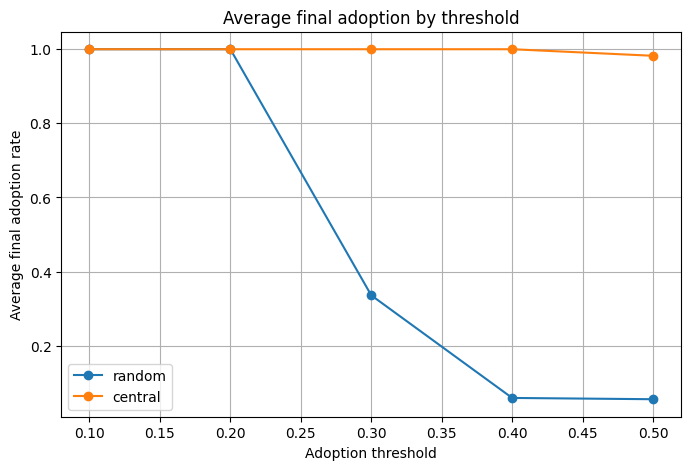

In [ ]:

plt.figure(figsize=(8, 5))

for strategy in strategies:
    data = summary[summary["strategy"] == strategy]

    plt.plot(
        data["threshold"],
        data["final_adoption_rate"],
        marker="o",
        label=strategy
    )


plt.xlabel("Adoption threshold")
plt.ylabel("Average final adoption rate")
plt.title("Average final adoption by threshold")

plt.legend()

plt.grid(True)

plt.show()

#### Interpretation

This plot shows the average final adoption rate for random and central targeting across different adoption thresholds.

At low thresholds (0.1 and 0.2), both strategies reach full adoption. This means that when people require only little social influence, low-carbon commuting spreads easily regardless of who adopts first.

From threshold 0.3 onward, the difference becomes large. Random targeting drops strongly, while central targeting remains close to full adoption. This suggests that central targeting is especially effective when people require stronger social influence before adopting.

###Plot 2: Adoption over Time for all thresholds



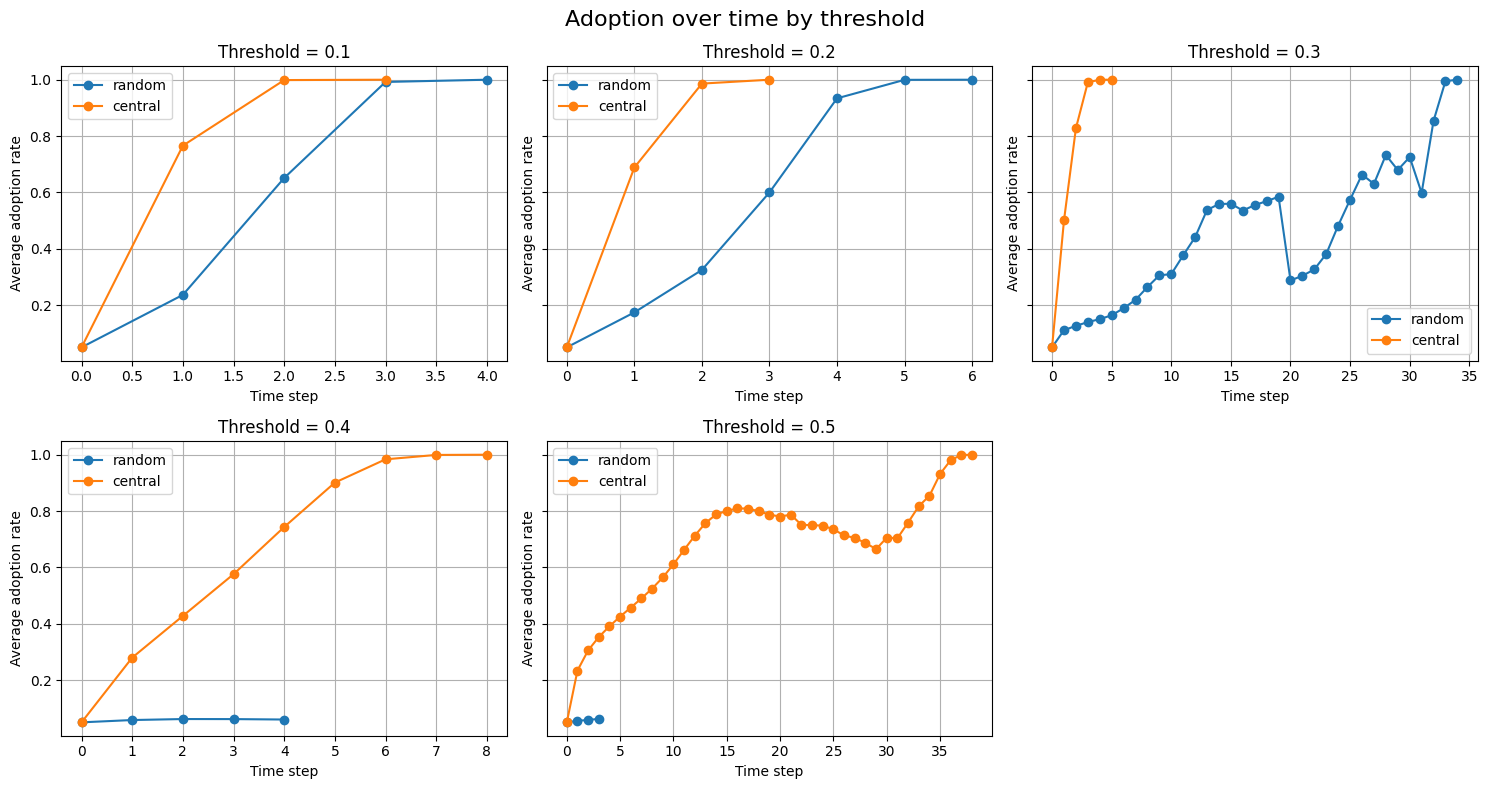

In [ ]:

time_summary_all = (
    time_series_df
    .groupby(["threshold", "strategy", "time"])["adoption_rate"]
    .mean()
    .reset_index()
)


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

axes = axes.flatten()

for i, threshold in enumerate(thresholds):
    ax = axes[i]

    for strategy in strategies:
        data = time_summary_all[
            (time_summary_all["threshold"] == threshold) &
            (time_summary_all["strategy"] == strategy)
        ]

        ax.plot(
            data["time"],
            data["adoption_rate"],
            marker="o",
            label=strategy
        )

    ax.set_title(f"Threshold = {threshold}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Average adoption rate")
    ax.grid(True)
    ax.legend()
axes[-1].axis("off")

fig.suptitle("Adoption over time by threshold", fontsize=16)

plt.tight_layout()
plt.show()

In some of the plots lines stop early because the simulation stops when no new people adopt. As you can see in graph with threshold 0.4 and 0.5. One way to adjust it can be that after adoption stops, the final adoption rate is carried forward until the final time step. This will make the time-series plots easier to compare.

#### Interpretation

This figure shows adoption over time separately for each threshold. Each subplot compares random and central targeting.

At lower thresholds, adoption spreads quickly for both strategies. As the threshold increases, random targeting becomes much weaker and often stops early. Central targeting still produces fast and large adoption across most thresholds.



###  Plot 3. Box plots of final adoption for threshold 0.3

###Why we used threshold = 0.3 for the boxplot

We use threshold 0.3 because it is the first threshold where random and central targeting clearly produce different outcomes.

At thresholds 0.1 and 0.2, both strategies reach full adoption, so a boxplot would not show much difference.

At thresholds 0.4 and 0.5, random targeting almost always fails and stays close to the initial adoption level.

Threshold 0.3 is the most useful case for showing variation across repeated simulations: central targeting consistently reaches full adoption, while random targeting varies much more across runs.

/tmp/ipykernel_2014/3257808447.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


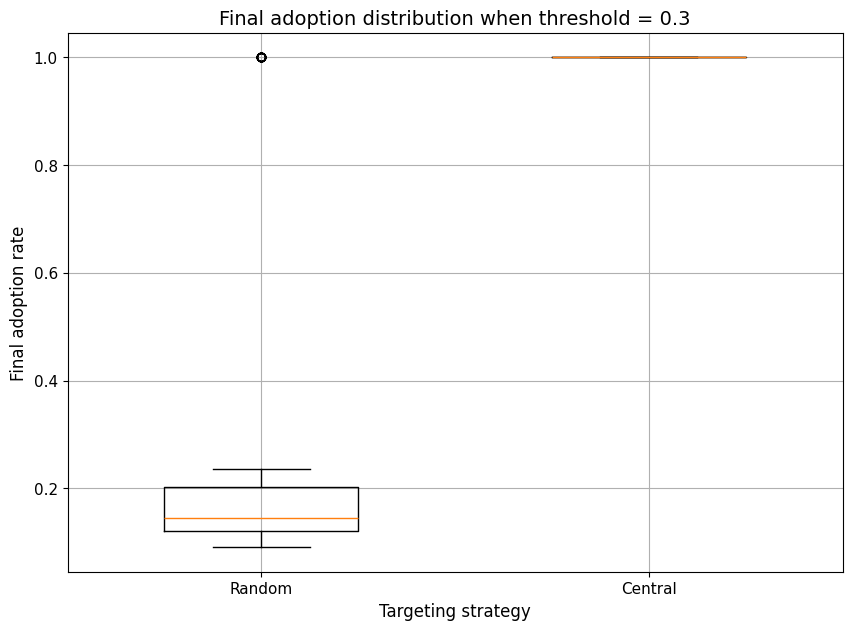

In [ ]:
box_data = results_df[results_df["threshold"] == 0.3]

random_values = box_data[
    box_data["strategy"] == "random"
]["final_adoption_rate"]

central_values = box_data[
    box_data["strategy"] == "central"
]["final_adoption_rate"]

plt.figure(figsize=(10, 7))

plt.boxplot(
    [random_values, central_values],
    labels=["Random", "Central"],
    widths=0.5
)

plt.xlabel("Targeting strategy", fontsize=12)
plt.ylabel("Final adoption rate", fontsize=12)
plt.title("Final adoption distribution when threshold = 0.3", fontsize=14)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True)
plt.show()

#### Interpretation

This boxplot shows the distribution of final adoption rates across 100 simulations when the threshold is 0.3.

Random targeting usually leads to low final adoption, but there are some rare cases where it reaches almost full adoption. This means random targeting is unstable: it can sometimes work if random initial adopters include well-connected people, but usually it does not create a large spread.

Central targeting consistently reaches full adoption in all simulations. This shows that central targeting is more reliable than random targeting at this threshold.

### Plot 4: Cascade Probability by threshold

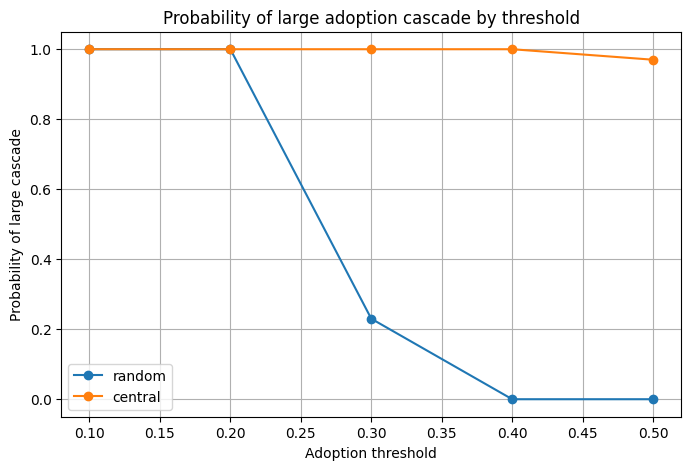

In [ ]:


plt.figure(figsize=(8, 5))

for strategy in strategies:
    data = cascade_summary[cascade_summary["strategy"] == strategy]

    plt.plot(
        data["threshold"],
        data["large_cascade"],
        marker="o",
        label=strategy
    )

plt.xlabel("Adoption threshold")
plt.ylabel("Probability of large cascade")
plt.title("Probability of large adoption cascade by threshold")
plt.legend()
plt.grid(True)
plt.show()

#### Interpretation

This plot shows the probability of a large adoption cascade, defined as final adoption above 50%.

At low thresholds (0.1 and 0.2), both random and central targeting create large cascades in all simulations. At threshold 0.3, central targeting still creates a large cascade in every simulation, while random targeting does so in only 21% of simulations. At thresholds 0.4 and 0.5, random targeting never creates a large cascade, while central targeting almost always does.

This shows that central targeting is more reliable for creating widespread adoption when adoption requires moderate or strong social influence.

## 11.Main Findings


The simulation results suggest that targeting central individuals can increase adoption of low-carbon commuting, especially when adoption requires moderate or strong social influence.

At low thresholds, both strategies work because adoption is easy. At higher thresholds, random targeting often fails because random initial adopters are too scattered to influence enough people. Central targeting works better because well-connected individuals expose more people to the behavior at the start.

These findings answer our research question in the simulation setting as  central targeting leads to higher and more reliable adoption than random targeting when adoption is not too easy.

## 12. References

The model and research question were based on literature about low-carbon mobility, peer influence, threshold models, agent-based modelling, and social network targeting.

- Granovetter, M. (1978). Threshold Models of Collective Behavior. *American Journal of Sociology, 83*(6), 1420–1443.

- Mundaca, L., Román-Collado, R., & Cansino, J. M. (2022). Assessing the impacts of social norms on low-carbon mobility options. *Energy Policy, 162*, 112814.

- Lambotte, M., de Palma, A., & Picard, N. (2023). Disentangling peer effects in transportation mode choice: The example of active commuting. *Journal of Environmental Economics and Management, 121*, 102868.

- Hoffmann, T., Ye, M., Zino, L., Cao, M., Rauws, W., & Bolderdijk, J. W. (2024). Overcoming inaction: An agent-based modelling study of social interventions that promote systematic pro-environmental change. *Journal of Environmental Psychology, 94*, 102221.

- Kim, D. A., Hwong, A. R., Stafford, D., Hughes, D. A., O’Malley, A. J., Fowler, J. H., & Christakis, N. A. (2015). Social network targeting to maximise population behaviour change: A cluster randomised controlled trial. *The Lancet, 386*(9989), 145–153.